In [8]:
import os
import sys

import pandas as pd
import numpy as np

import scanpy as sc
import scipy.sparse as sp
import anndata as ad
from scipy import stats

import decoupler as dc
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text   

sys.path.insert(1, '../../.')
from McCauley_utils import initialize_mod_and_trainer, all_data


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PLSRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [9]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [10]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

Based on (1) perturbation of interest (TGFB1) (2) cell types of interest (Basal, Club) and (3) the scLEMBAS model fit, we define a subnetwork consisting of the most relevant nodes.

In [11]:
subnetwork = pd.read_csv(
    os.path.join(data_path, 'processed', 'consensus_subnetwork_edges_TGFB1^BasalClub.csv')
)



In [12]:
n_nodes = len(set(sn_ppis[source_label]).union(set(sn_ppis[target_label])))
subnetwork_nodes = sorted(set(subnetwork['source']).union(set(subnetwork['target'])))
n_subnetwork_nodes = len(subnetwork_nodes)


print('{}  of {} edges and {} of {} nodes are retained in the subnetwork'.format(
    subnetwork.shape[0], sn_ppis.shape[0],
    n_subnetwork_nodes, n_nodes
))


5394  of 17597 edges and 726 of 2504 nodes are retained in the subnetwork


# Subnetwork Expression

Let's look at whether the identified subnetwork nodes show expression differences between cell types. We download the HLCA core data from HCA [here](https://data.humancellatlas.org/hca-bio-networks/lung/atlases/lung-v1-0)

In [ ]:
adata_cz = sc.read_h5ad(os.path.join(data_path, 'raw', '4cb45d80-499a-48ae-a056-c71ac3552c94.h5ad'))

Tissue is only one and disease is only healthy. Developmental stage, we filter for those between 24 and 54 years of age. 

In [ ]:
include_developmental = [
'24-year-old stage',
 '25-year-old stage',
 '26-year-old stage',
 '27-year-old stage',
 '29-year-old stage',
 '30-year-old stage',
 '31-year-old stage',
 '33-year-old stage',
 '34-year-old stage',
 '35-year-old stage',
 '36-year-old stage',
 '37-year-old stage',
 '38-year-old stage',
 '40-year-old stage',
 '41-year-old stage',
 '42-year-old stage',
 '44-year-old stage',
 '46-year-old stage',
 '47-year-old stage',
 '49-year-old stage',
 '51-year-old stage',
 '52-year-old stage',
 '53-year-old stage',
 '54-year-old stage'
  'fourth decade stage'             
]
mask = adata_cz.obs.development_stage.isin(include_developmental)
adata_cz = adata_cz[mask].copy()


Filter to cell types of interest:

In [ ]:
# backup = adata_cz.copy()

In [ ]:
cell_types = ['club cell', 'respiratory basal cell']
mask = adata_cz.obs.cell_type.isin(cell_types)
adata_cz = adata_cz[mask].copy()
adata_pb = sc.get.aggregate(adata_cz, by="cell_type", func="mean")

adata_cz = adata_cz[adata_cz.obs['ann_finest_level'] != 'Club (nasal)'].copy()

Map to gene symbols and filter to subnetwork nodes:

In [ ]:
mapper = pd.read_csv(os.path.join(data_path, 'raw', 'hgnc_complete_set.txt'), sep='\t', low_memory=False)
mapper = mapper[['symbol', 'ensembl_gene_id']].copy()

# --- Helper: remap a (matrix, ensg_ids) pair to symbol space ---
def remap_to_symbols(X, ensg_ids, mapper):
    var_df = pd.DataFrame({'ensembl_gene_id': ensg_ids, 'gene_idx': np.arange(len(ensg_ids))})
    merged = var_df.merge(mapper, on='ensembl_gene_id', how='inner')
    
    X_remapped = X[:, merged['gene_idx'].values]
    
    symbols = merged['symbol'].values
    unique_symbols, inverse = np.unique(symbols, return_inverse=True)
    n_expanded = len(symbols)
    n_symbols = len(unique_symbols)
    aggregator = sp.csr_matrix(
        (np.ones(n_expanded), (np.arange(n_expanded), inverse)),
        shape=(n_expanded, n_symbols),
    )
    X_symbols = X_remapped @ aggregator
    return X_symbols, unique_symbols

# --- 1. Remap .X ---
X_symbols, unique_symbols_X = remap_to_symbols(
    adata_cz.X,
    adata_cz.var.index.values,
    mapper,
)

# --- 2. Remap .raw.X (uses raw's own var, which may differ from .X's var) ---
raw_X_symbols, unique_symbols_raw = remap_to_symbols(
    adata_cz.raw.X,
    adata_cz.raw.var.index.values,
    mapper,
)

# --- 3. Build new AnnData for .X ---
adata_new = ad.AnnData(
    X=X_symbols,
    obs=adata_cz.obs.copy(),
    var=pd.DataFrame(index=unique_symbols_X),
)
adata_new.var_names.name = 'symbol'

# --- 4. Build a separate AnnData for .raw and assign it ---
# .raw must be set from a full AnnData object; AnnData will store its X and var
raw_adata = ad.AnnData(
    X=raw_X_symbols,
    obs=adata_cz.obs.copy(),     # obs is required but won't actually be stored in .raw
    var=pd.DataFrame(index=unique_symbols_raw),
)
raw_adata.var_names.name = 'symbol'
adata_new.raw = raw_adata

adata_cz = adata_new

# --- 5. Subset to subnetwork ---
available = [g for g in subnetwork_nodes if g in adata_cz.var_names]
missing = [g for g in subnetwork_nodes if g not in adata_cz.var_names]
print('Of the {} nodes in the subnetwork, {} are mapped and {} are unmapped'.format(
    n_subnetwork_nodes,
    len(available),
    len(missing),
))
adata_cz = adata_cz[:, available].copy()

In [26]:
adata_cz.write_h5ad(os.path.join(data_path, 'processed', 'cz_hlca.h5ad'))

## DE between the cell types:

In [13]:
adata_cz = sc.read_h5ad(os.path.join(data_path, 'processed', 'cz_hlca.h5ad'))

In [14]:
padj_thresh, lfc_thresh = 0.05, 1.5

In [15]:

# ---- 1. Pseudobulk by (sample, cell_type) using RAW counts ----
adata_cz.layers['counts'] = adata_cz.raw[:, adata_cz.var_names].X.copy()
pdata = dc.get_pseudobulk(
    adata_cz,
    sample_col='sample',
    groups_col='cell_type',   
    layer='counts',           
    mode='sum',               # sum counts within each (sample, cell_type) - expected by deseq2
    min_cells=10,             
    min_counts=1000,         
)

# ---- 2. Run DESeq2 ----
counts_df = pd.DataFrame(
    pdata.X.astype(int),
    index=pdata.obs_names,
    columns=pdata.var_names,
)
metadata = pdata.obs[['sample', 'cell_type']].copy()

inference = DefaultInference(n_cpus=1)  # avoids the broken process pool

dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata,
    design_factors='cell_type',
    refit_cooks=True,
    inference=inference,
)
dds.deseq2()

# Specify the contrast: club vs basal (basal is the baseline)
# DeseqStats contrast format: [factor, level_to_test, reference_level]
ct_a, ct_b = 'respiratory basal cell', 'club cell'  
stat_res = DeseqStats(dds, contrast=['cell_type', ct_b, ct_a], inference = inference)
stat_res.summary()
res = stat_res.results_df.copy()

# ---- 3. Filter & rank ----
sig = res[(res['padj'] < padj_thresh) & (res['log2FoldChange'].abs() > lfc_thresh)].copy()
sig = sig.sort_values('log2FoldChange', key=abs, ascending=False)


/tmp/ipykernel_3455807/2402323032.py:23: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.76 seconds.

Fitting dispersion trend curve...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.39 seconds.

Fitting LFCs...
... done in 2.01 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 4 outlier genes.

Fitting dispersions...
... done in 0.00 seconds.

Fitting MAP dispersions...
... done in 0.00 seconds.

Fitting LFCs...
... done in 0.00 seconds.

Running Wald tests...
... done in 0.06 seconds.



Log2 fold change & Wald test p-value: cell_type club cell vs respiratory basal cell
           baseMean  log2FoldChange     lfcSE      stat        pvalue  \
symbol                                                                  
ABL1       6.178880        0.345862  0.226338  1.528076  1.264936e-01   
ABL2       8.813759       -0.445246  0.258243 -1.724138  8.468294e-02   
ABRAXAS1   7.971362       -0.896092  0.224457 -3.992262  6.544589e-05   
ACP1      64.608308        0.436802  0.075027  5.821965  5.815990e-09   
ACVR1     10.125464        0.901282  0.158967  5.669625  1.431103e-08   
...             ...             ...       ...       ...           ...   
ZBTB17     5.385019       -0.053831  0.209054 -0.257499  7.967937e-01   
ZEB2       1.502004        1.464576  0.603226  2.427905  1.518633e-02   
ZFYVE9     3.881383       -0.796862  0.334889 -2.379483  1.733695e-02   
ZMIZ1      7.433921       -0.201347  0.294048 -0.684741  4.935072e-01   
ZNF420     5.674262       -0.424364  0.2

In [16]:
sig_genes = sig.index.tolist()
sig_tfs = set(sig_genes).intersection(tf_adata.var_names)
sig_ligands = set(tf_adata.obs[pert_col].unique()).intersection(sig_genes)
print('Of the {} significant nodes, {} are transcription factors and {} are input ligands'.format(
    len(sig), len(sig_tfs), len(sig_ligands)
))


Of the 70 significant nodes, 19 are transcription factors and 2 are input ligands


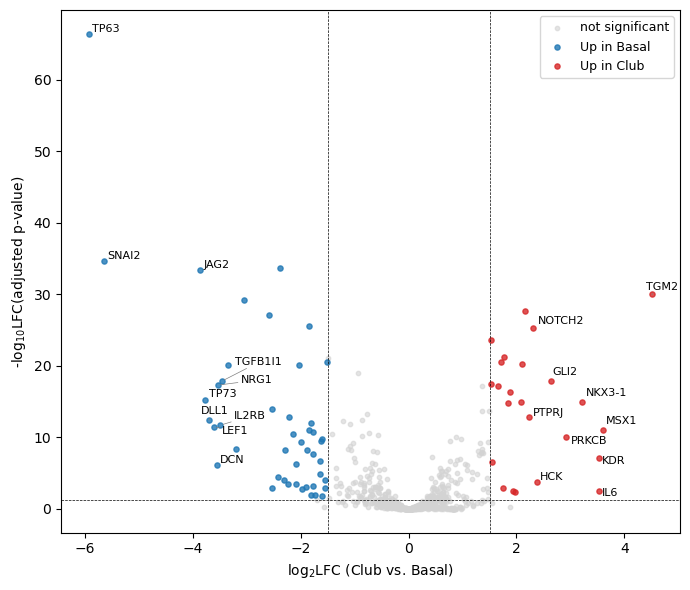

In [17]:
res_plot = res.dropna(subset=['padj']).copy()
res_plot['-log10padj'] = -np.log10(res_plot['padj'].clip(lower=1e-300))

# Categorize genes
up   = (res_plot['log2FoldChange'] >  lfc_thresh) & (res_plot['padj'] < padj_thresh)
down = (res_plot['log2FoldChange'] < -lfc_thresh) & (res_plot['padj'] < padj_thresh)
ns   = ~(up | down)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(res_plot.loc[ns,   'log2FoldChange'], res_plot.loc[ns,   '-log10padj'],
           s=10, color='lightgrey', alpha=0.6, label='not significant')
ax.scatter(res_plot.loc[down, 'log2FoldChange'], res_plot.loc[down, '-log10padj'],
           s=14, color='#1f77b4', alpha=0.8, label='Up in Basal')
ax.scatter(res_plot.loc[up,   'log2FoldChange'], res_plot.loc[up,   '-log10padj'],
           s=14, color='#d62728', alpha=0.8, label='Up in Club')

# Label top N by absolute LFC among significant
# top_n = 15
sig_genes = res_plot[(up | down)].copy()
# top_label = sig_genes.reindex(
#     sig_genes['log2FoldChange'].abs().sort_values(ascending=False).index
# ).head(top_n)

# texts = [
#     ax.text(row['log2FoldChange'], row['-log10padj'], gene, fontsize=8)
#     for gene, row in top_label.iterrows()
# ]
# adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

top_n_per_direction = 10
top_up   = sig_genes[sig_genes['log2FoldChange'] > 0].nlargest(top_n_per_direction,  'log2FoldChange')
top_down = sig_genes[sig_genes['log2FoldChange'] < 0].nsmallest(top_n_per_direction, 'log2FoldChange')
top_label = pd.concat([top_up, top_down])

texts = [
    ax.text(row['log2FoldChange'], row['-log10padj'], gene, fontsize=8)
    for gene, row in top_label.iterrows()
]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))




# Threshold lines
ax.axhline(-np.log10(padj_thresh), ls='--', lw=0.5, color='k')
ax.axvline( lfc_thresh, ls='--', lw=0.5, color='k')
ax.axvline(-lfc_thresh, ls='--', lw=0.5, color='k')

ax.set_xlabel(r'log$_2$LFC (Club vs. Basal)')
ax.set_ylabel(r'-log$_{10}$LFC(adjusted p-value)')
ax.legend(loc='upper right', frameon=True, fontsize=9)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



### Relevance to in-silico perturbations
- The question: why do basal and club respond differently to the same TGFβ1 stimulus, and what perturbations would make one response look like the other?

#### Prioritization of perturbation candidates

Given that the subnetwork was derived from gradient-based importance scores when running a forward pass for TGFβ1 in each cell type, the DE genes within it represent **nodes the model uses to compute the TGFβ1 response, with cell-type-specific differential usage**. The goal is to identify perturbations that shift one cell type's TGFβ1 response toward the other's—prioritizing nodes that mechanistically gate or shape the response, rather than just correlate with cell identity.

Candidates are organized into tiers by mechanistic position relative to the TGFβ1 response.

---

##### Tier 1 — Direct TGFβ pathway modulators

These genes sit on the canonical TGFβ pathway itself and act as response amplifiers, modulators, or feedback regulators. Perturbing them tests whether **rebalancing the TGFβ signaling machinery** between cell types is sufficient to converge their responses. Mechanism is direct and interpretable, with strong literature priors for what should happen.

- TGFB1I1 (Hic-5) — TGFβ-induced; acts as a coactivator/modulator of downstream signaling. High baseline in basal "primes" amplified TGFβ response.
- DCN (decorin) — extracellular matrix proteoglycan that binds TGFβ ligand directly, modulating bioavailability. Perturbation rebalances the *input* to the pathway, not just the output.
- SNAI2 (Slug) — TGFβ target and feedforward amplifier driving downstream EMT program. Knockdown should specifically dampen the basal EMT response.
- TGM2 (tissue transglutaminase) — club-specific TGFβ target. Tests whether club's distinctive matrix/secretory remodeling response defines its divergence from basal.

---

##### Tier 2 — Identity/state determinants gating the response landscape

These genes don't directly transduce TGFβ but **define the cell-state context** in which TGFβ arrives, determining which response programs are accessible. Perturbing them tests a deeper hypothesis: are the divergent TGFβ responses a consequence of the cells being in different states, such that shifting state shifts response? Notch components in particular have well-documented TGFβ–Notch crosstalk, making them dual-mechanism targets (identity + signal modulation).

- TP63 — basal cell master regulator. Knockdown in basal tests whether dismantling basal identity shifts the TGFβ response toward club-like.
- NOTCH2 — receptor expressed in club cells. Pairs with basal-expressed JAG2/DLL1.
- JAG2, DLL1 — Notch ligands expressed in basal cells.

The clean ligand–receptor split (basal: ligands; club: receptor) gives a directional perturbation hypothesis: perturbations that swap Notch directionality should shift each cell type's TGFβ response toward the other's. Particularly attractive because Notch components *redirect* signaling rather than just blocking it—reduces the risk of "successful" perturbations that simply abolish the TGFβ response.

---

##### Tier 3 — Lineage TFs and downstream effectors (lower priority)

These genes are differentially expressed between cell types but are likely **consequences of cell identity rather than drivers of the differential TGFβ response**. Lower leverage as perturbation targets because they're either too far downstream (effectors) or change identity broadly without specifically redirecting the TGFβ response.

- Lineage/developmental TFs: TP73, LEF1, MSX1, NKX3-1, GLI2 — DE because of cell type, but not strongly positioned to gate the TGFβ response itself.
- Downstream signaling/effectors: KDR (VEGFR2), PRKCB, PTPRJ, IL2RB, NRG1, HCK, IL6 — affected by TGFβ but not gating the response. Perturbation changes specific downstream readouts, not global response shape.

---

## Pathway Enrichment

In [18]:
# import pandas as pd
# import numpy as np
# from scipy.stats import fisher_exact
# from statsmodels.stats.multitest import multipletests


# # ---- Custom ORA with explicit background ----
# def ora_with_background(hits, net, background, source='geneset', target='genesymbol', min_n=5):
#     """ORA with explicit background list. Returns DataFrame with p-values and FDR."""
#     hits = set(hits) & set(background)
#     bg = set(background)

#     results = []
#     for geneset, group in net.groupby(source):
#         gs_genes = set(group[target]) & bg
#         if len(gs_genes) < min_n:
#             continue

#         a = len(hits & gs_genes)
#         b = len(hits) - a
#         c = len(gs_genes) - a
#         d = len(bg) - len(hits) - c

#         odds, pval = fisher_exact([[a, b], [c, d]], alternative='greater')
#         results.append({
#             'geneset': geneset,
#             'n_geneset': len(gs_genes),
#             'n_hits_in_set': a,
#             'odds_ratio': odds,
#             'p_value': pval,
#         })

#     df = pd.DataFrame(results)
#     if len(df) == 0:
#         return df
#     df['FDR'] = multipletests(df['p_value'], method='fdr_bh')[1]
#     return df.sort_values('p_value').reset_index(drop=True)


# # ---- Library fetch: try OmniPath/decoupler, fall back to gseapy ----
# # Map of friendly names -> (decoupler resource + filter, gseapy library name)
# LIBRARY_MAP = {
#     'hallmark': {
#         'decoupler': ('MSigDB', lambda df: df[df['collection'] == 'hallmark']),
#         'gseapy': 'MSigDB_Hallmark_2020',
#     },
#     'kegg': {
#         'decoupler': ('MSigDB', lambda df: df[df['collection'] == 'kegg_pathways']),
#         'gseapy': 'KEGG_2021_Human',
#     },
#     'reactome': {
#         'decoupler': ('MSigDB', lambda df: df[df['collection'] == 'reactome_pathways']),
#         'gseapy': 'Reactome_2022',
#     },
#     'wikipathways': {
#         'decoupler': ('MSigDB', lambda df: df[df['collection'] == 'wikipathways']),
#         'gseapy': 'WikiPathways_2019_Human',
#     },
#     'msigdb_c2': {
#         # MSigDB C2 = curated gene sets (KEGG, Reactome, BioCarta, etc. combined)
#         'decoupler': ('MSigDB', lambda df: df[df['collection'].isin(
#             ['kegg_pathways', 'reactome_pathways', 'wikipathways', 'biocarta_pathways', 'pid_pathways']
#         )]),
#         'gseapy': 'MSigDB_Curated_2024',  # may need to check name in your gseapy version
#     },
# }


# def fetch_geneset_library(library):
#     """Fetch a gene set library by friendly name. Tries decoupler/OmniPath first, falls back to gseapy.
#     Returns a long-format DataFrame with columns ['geneset', 'genesymbol']."""
#     if library not in LIBRARY_MAP:
#         raise ValueError(f"Unknown library '{library}'. Choose from: {list(LIBRARY_MAP.keys())}")

#     dc_resource, dc_filter = LIBRARY_MAP[library]['decoupler']
#     gp_name = LIBRARY_MAP[library]['gseapy']

#     # Try decoupler/OmniPath
#     try:
#         import decoupler as dc
#         raw = dc.get_resource(dc_resource)
#         net = dc_filter(raw).copy()
#         net = net[['geneset', 'genesymbol']].drop_duplicates()
#         if len(net) == 0:
#             raise RuntimeError(f'Decoupler returned empty result for {library}')
#         print(f"Loaded '{library}' from OmniPath: {net['geneset'].nunique()} sets, {len(net)} rows")
#         return net
#     except Exception as e:
#         print(f"OmniPath fetch failed for '{library}' ({type(e).__name__}: {e}); falling back to gseapy")

#     # Fall back to gseapy
#     import gseapy as gp
#     available = set(gp.get_library_name())
#     if gp_name not in available:
#         # Try to find a close match (gseapy library names change with releases)
#         candidates = [n for n in available if gp_name.split('_')[0] in n]
#         raise RuntimeError(
#             f"gseapy library '{gp_name}' not found. Close matches: {candidates[:5]}"
#         )

#     d = gp.get_library(gp_name)
#     rows = [(s, g) for s, gs in d.items() for g in gs]
#     net = pd.DataFrame(rows, columns=['geneset', 'genesymbol']).drop_duplicates()
#     print(f"Loaded '{library}' from gseapy ({gp_name}): {net['geneset'].nunique()} sets, {len(net)} rows")
#     return net


# def run_directional_ora(res, sig_genes, library, lfc_col='log2FoldChange',
#                         up_label='up_in_club', down_label='up_in_basal'):
#     """Run ORA for up- and down-regulated genes against a chosen library.

#     Parameters
#     ----------
#     res : DataFrame with all tested genes (index = gene symbols)
#     sig_genes : DataFrame of significant genes (subset of res, index = gene symbols)
#     library : str, one of LIBRARY_MAP keys
#     lfc_col : column in sig_genes containing log fold change
#     up_label, down_label : labels for the two directions
#     """
#     net = fetch_geneset_library(library)

#     background = res.index.tolist()
#     up_hits = sig_genes[sig_genes[lfc_col] > 0].index.tolist()
#     down_hits = sig_genes[sig_genes[lfc_col] < 0].index.tolist()

#     print(f'Background: {len(background)}; up hits: {len(up_hits)}; down hits: {len(down_hits)}')

#     ora_up = ora_with_background(up_hits, net, background)
#     ora_up['direction'] = up_label

#     ora_down = ora_with_background(down_hits, net, background)
#     ora_down['direction'] = down_label

#     ora = pd.concat([ora_up, ora_down], ignore_index=True)
#     ora['library'] = library
#     return ora.sort_values('FDR' if 'FDR' in ora.columns else 'p_value').reset_index(drop=True)

# ora = run_directional_ora(res, sig_genes, library='reactome')
# fdr_thresh = 0.1

# print(f"\nSignificant pathways at FDR < {fdr_thresh}: {(ora['FDR'] < fdr_thresh).sum()}")



In [19]:
# # ---- Filter and rank ----

# top_up = (ora[(ora['direction'] == 'up_in_club') & (ora['FDR'] < fdr_thresh)]
#           .sort_values('odds_ratio', ascending=False)
#           .head(10))

# top_down = (ora[(ora['direction'] == 'up_in_basal') & (ora['FDR'] < fdr_thresh)]
#             .sort_values('odds_ratio', ascending=False)
#             .head(10))

# print(f'Up in club (FDR < {fdr_thresh}): {len(top_up)} pathways')
# print(f'Up in basal (FDR < {fdr_thresh}): {len(top_down)} pathways')


# # ---- Plot ----
# fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# for ax, df, title, color in [
#     (axes[0], top_up, 'Up in club', '#d62728'),
#     (axes[1], top_down, 'Up in basal', '#1f77b4'),
# ]:
#     if len(df) == 0:
#         ax.text(0.5, 0.5, f'No pathways\nFDR < {fdr_thresh}',
#                 ha='center', va='center', transform=ax.transAxes, fontsize=12)
#         ax.set_title(title)
#         ax.set_xticks([]); ax.set_yticks([])
#         continue

#     # Sort ascending so largest OR is on top in horizontal bar plot
#     df = df.sort_values('odds_ratio', ascending=True)

#     bars = ax.barh(df['geneset'], df['odds_ratio'], color=color, alpha=0.85)

#     # Annotate with -log10(FDR) on each bar
#     for bar, fdr in zip(bars, df['FDR']):
#         ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
#                 f'-log10(FDR)={-np.log10(fdr):.1f}',
#                 va='center', fontsize=8)

#     ax.set_xlabel('Odds ratio')
#     ax.set_title(f'{title} (FDR < {fdr_thresh})')
#     ax.axvline(1, color='gray', linestyle='--', linewidth=0.8)

# plt.tight_layout()
# plt.show()

# Bias Term Concordance

Here, we compare the data-driven nodes distinguishing these cell types to those that are most important in the subnetwork. This tells us whether the model is capturing the relevant genes to distinguish the cell types in this case.

Get the node ranks as defined by Nikos:

In [20]:
bias_type = 'categorical'
node_ranks = pd.read_csv(os.path.join(
    data_path, 'processed', 'node_importance_results', 'aggregated_node_ranks_{}.csv'.format(bias_type)))

node_ranks.set_index('node_name', inplace = True)


In [21]:
sig_genes = res.index.tolist()
sa = stats.spearmanr(
            -node_ranks.loc[sig_genes, 'median_rank'], 
            res.loc[sig_genes, 'log2FoldChange'].abs()#
        ).statistic

sig_genes = res[(res.padj <= padj_thresh)].index.tolist()
sag = stats.spearmanr(
            -node_ranks.loc[sig_genes, 'median_rank'], 
            res.loc[sig_genes, 'log2FoldChange'].abs()#
        ).statistic

sig_genes = res[(res.padj <= padj_thresh) & (res.log2FoldChange.abs()>lfc_thresh)].index.tolist()
s_corr = stats.spearmanr(
            -node_ranks.loc[sig_genes, 'median_rank'], 
            res.loc[sig_genes, 'log2FoldChange'].abs()#
        ).statistic

print('The spearman correlation between node rank (by median importance score) and absolute LFC of significantly DE genes that pass the LFC threshold is: {:.4f}'.format(s_corr))
print()
print('Compare this to {:.2f} and {:.2f} correlation values for all significant genes and all subnetwork genes, respectively'.format(sag, sa))



The spearman correlation between node rank (by median importance score) and absolute LFC of significantly DE genes that pass the LFC threshold is: 0.3244

Compare this to 0.17 and 0.08 correlation values for all significant genes and all subnetwork genes, respectively


In [22]:
sig_genes_ = sorted(set(sig_genes).difference(sig_tfs.union(sig_ligands)))
s_corr = stats.spearmanr(
            -node_ranks.loc[sig_genes_, 'median_rank'], 
            res.loc[sig_genes_, 'log2FoldChange'].abs()#
        ).statistic
print('The spearman correlation when disregarding ligands/TFs is: {:4f}'.format(s_corr))


The spearman correlation when disregarding ligands/TFs is: 0.319251


The fact that the correlation doesn't change when disregarding the ligands/TFs tells us this is still driven by the learned intracellular node values.

This tells us that the model is capturing the importance in the categorical bias relevant to distinguishing these two cell types for the most distinguishing nodes, whereas the rest of the nodes play less of a crucial role. 

Visualize:

In [23]:
viz_df = pd.DataFrame(
    data = {'node_rank': -node_ranks.loc[sig_genes, 'median_rank'], 
           'abs_lfc': res.loc[sig_genes, 'log2FoldChange'].abs()}
)
viz_df = viz_df.rank(axis=0, ascending=True) / viz_df.shape[0]


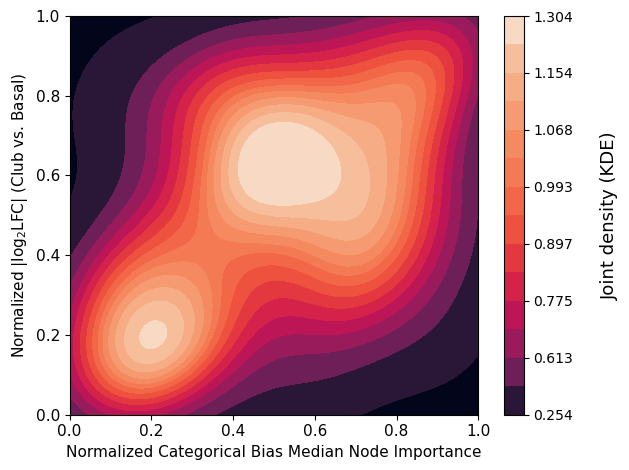

In [24]:
fig, ax = plt.subplots()
sns.kdeplot(
    x='node_rank', y='abs_lfc', data=viz_df,
    fill=True, levels=15, thresh=0.01,
     bw_adjust=1, 
    cmap = 'rocket', # mako
    cbar = True,
    clip=((0, 1), (0, 1)),
    cbar_kws={"label": "Joint density (KDE)"}
)

ax.set_ylabel(r'Normalized |log$_2$LFC| (Club vs. Basal)', fontsize=11)
ax.set_xlabel('Normalized Categorical Bias Median Node Importance', fontsize = 11)

ax.tick_params(axis='both', which='major', labelsize=11)
ax.tick_params(axis='both', which='minor', labelsize=11)

cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("Joint density (KDE)", fontsize=13, rotation=90, labelpad=20)
ax.set_facecolor('#03051A')
fig.tight_layout()



# Centrality

Here we look at the association with centrality. We use the centrality of the full network rather than the subnetwork, because we want to get the true topology of the nodes relative to the other metrics, not the subnetwork one.


In [25]:
import networkx as nx

In [26]:
# G = nx.from_pandas_edgelist(
#     subnetwork, 
#     source='source', 
#     target='target', 
#     edge_attr='mean_weight',  # pulls the weight column into edge attributes
#     create_using=nx.DiGraph()  # or nx.Graph() if undirected
# )

G = nx.from_pandas_edgelist(
    sn_ppis, 
    source=source_label, 
    target=target_label, 
#     edge_attr='mean_weight',  # pulls the weight column into edge attributes
    create_using=nx.DiGraph()  # or nx.Graph() if undirected
)

centralities = pd.DataFrame({
#     'in_degree': dict(G.in_degree()),
#     'out_degree': dict(G.out_degree()),
#     'total_degree': dict(G.degree()),
#     'in_degree_centrality': nx.in_degree_centrality(G),
#     'out_degree_centrality': nx.out_degree_centrality(G),
#     'betweenness': nx.betweenness_centrality(G),
#     'closeness': nx.closeness_centrality(G),
    'pagerank': nx.pagerank(G),
#     'clustering': nx.clustering(G),
})

# hubs, authorities = nx.hits(G)
# centralities['hub_score'] = pd.Series(hubs)
# centralities['authority_score'] = pd.Series(authorities)


In [27]:
sig_genes = res[(res.padj <= padj_thresh) & (res.log2FoldChange.abs()>lfc_thresh)].index.tolist()

s_corr = stats.spearmanr(
        -node_ranks.loc[sig_genes, 'median_rank'], 
        centralities.loc[sig_genes, 'pagerank']
    ).statistic
print('The spearman correlation between node rank (by median importance score) and pagerank centrality: {:.4f}'.format(s_corr))


The spearman correlation between node rank (by median importance score) and pagerank centrality: 0.4858


In [28]:
sig_genes = res[(res.padj <= padj_thresh) & (res.log2FoldChange.abs()>lfc_thresh)].index.tolist()

s_corr = stats.spearmanr(
        res.loc[sig_genes, 'log2FoldChange'], 
        centralities.loc[sig_genes, 'pagerank']
    ).statistic
print('The spearman correlation between pagerank centrality and absolute LFC of significantly DE genes that pass the LFC threshold is: {:.4f}'.format(s_corr))



The spearman correlation between pagerank centrality and absolute LFC of significantly DE genes that pass the LFC threshold is: -0.1239


In [29]:
viz_df = pd.DataFrame(
    data = {'node_rank': -node_ranks.loc[sig_genes, 'median_rank'], 
           'abs_lfc': res.loc[sig_genes, 'log2FoldChange'].abs(), 
            'centrality': centralities.loc[sig_genes, 'pagerank']
           }
)
viz_df = viz_df.rank(axis=0, ascending=True) / viz_df.shape[0]


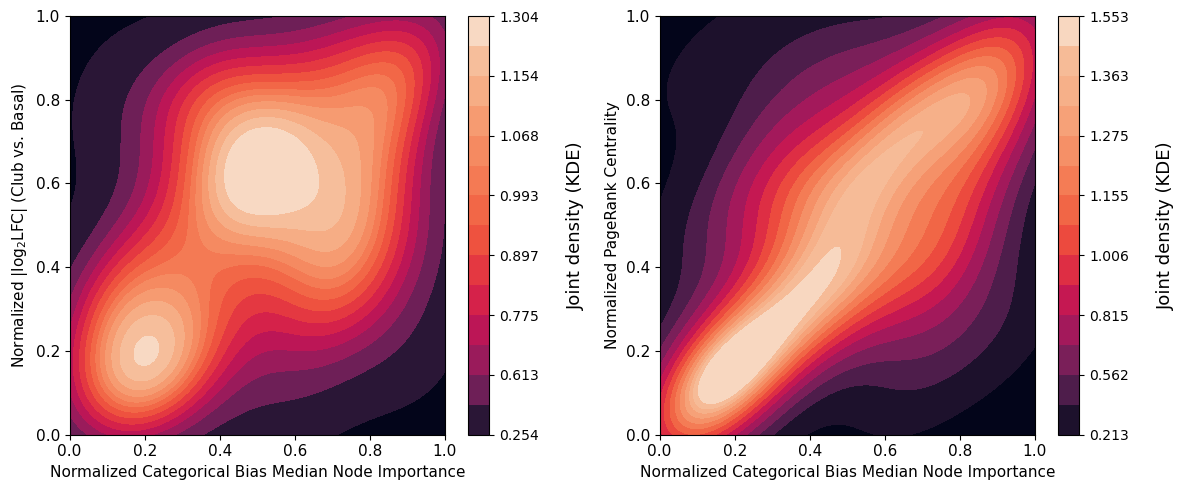

In [30]:
viz_df = pd.DataFrame(
    data={'node_rank': -node_ranks.loc[sig_genes, 'median_rank'], 
          'abs_lfc': res.loc[sig_genes, 'log2FoldChange'].abs(), 
          'centrality': centralities.loc[sig_genes, 'pagerank']}
)
viz_df = viz_df.rank(axis=0, ascending=True) / viz_df.shape[0]

fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

# --- Left subplot: node_rank vs abs_lfc ---
sns.kdeplot(
    x='node_rank', y='abs_lfc', data=viz_df,
    fill=True, levels=15, thresh=0.01,
    bw_adjust=1,
    cmap='rocket',
    cbar=True,
    clip=((0, 1), (0, 1)),
    cbar_kws={"label": "Joint density (KDE)"},
    ax=axes[0]
)
axes[0].set_ylabel(r'Normalized |log$_2$LFC| (Club vs. Basal)', fontsize=11)
axes[0].set_xlabel('Normalized Categorical Bias Median Node Importance', fontsize=11)
axes[0].tick_params(axis='both', which='major', labelsize=11)
axes[0].tick_params(axis='both', which='minor', labelsize=11)
axes[0].set_facecolor('#03051A')

# --- Right subplot: node_rank vs centrality ---
sns.kdeplot(
    x='node_rank', y='centrality', data=viz_df,
    fill=True, levels=15, thresh=0.01,
    bw_adjust=1,
    cmap='rocket',
    cbar=True,
    clip=((0, 1), (0, 1)),
    cbar_kws={"label": "Joint density (KDE)"},
    ax=axes[1]
)
axes[1].set_ylabel('Normalized PageRank Centrality', fontsize=11)
axes[1].set_xlabel('Normalized Categorical Bias Median Node Importance', fontsize=11)
axes[1].tick_params(axis='both', which='major', labelsize=11)
axes[1].tick_params(axis='both', which='minor', labelsize=11)
axes[1].set_facecolor('#03051A')

# Style both colorbars
# fig.axes now has 4 entries: [ax0, ax1, cbar0, cbar1]
for cbar_ax in fig.axes[2:]:
    cbar_ax.set_ylabel("Joint density (KDE)", fontsize=13, rotation=90, labelpad=20)

fig.tight_layout()


# In silico Perturbations

Here, we see if we can get one cell type response to behave like the other according to these three variables. 

## Identify Candidate Nodes

Our DE analysis got us down to 70 genes, and of these 19 are TFs and 2 are ligands. Here, we want to focus on intracellular nodes that can alter downstream TFs to counter the perturbation effect. This gets us to 49 nodes. 

We will take the top 5 of these candidate nodes using a composite score as follows:
- we will strongly weight node importance (0.6)
- we will downweight LFC (0.2): we already used it for filtering to these 70 genes, and now we want things that would be captured by the model that aren't necessarily apparent from a simple DGEA
- we will downweight centrality (0.2) - the intuition behind this is that we want to be able to target nodes that won't have pleiotropic effects, but rather hae a really targetted effect.

In [31]:
candidate_nodes = sorted(set(sig_genes).difference(sig_tfs.union(sig_ligands)))

scores = pd.DataFrame(
    data={'node_rank': -node_ranks.loc[candidate_nodes, 'median_rank'], 
          'abs_lfc': res.loc[candidate_nodes, 'log2FoldChange'].abs(), 
          'centrality': centralities.loc[candidate_nodes, 'pagerank']}
)
scores = scores.rank(axis=0, ascending=True) / scores.shape[0]
scores['centrality_inv'] = 1-scores['centrality']
scores['abs_lfc_inv'] = 1-scores['abs_lfc']


scores['composite'] = (
    0.6 * scores['node_rank'] +  # primary signal
    0.2 * scores['abs_lfc_inv'] +           # prioritize model picks missed by DGEA
    0.2 * scores['centrality_inv']          # network propagation
)


scores.sort_values('composite', ascending=False, inplace = True)

for col in scores.columns:
    if col == 'composite':
        continue
    scores.rename(columns = {col: 'norm_{}'.format(col)}, inplace = True)
        
scores.head()


,norm_node_rank,norm_abs_lfc,norm_centrality,norm_centrality_inv,norm_abs_lfc_inv,composite
MELK,0.836735,0.285714,0.142857,0.857143,0.714286,0.816327
MMP2,0.979592,0.224490,0.877551,0.122449,0.775510,0.767347
PAK5,0.867347,0.428571,0.367347,0.632653,0.571429,0.761224
DCN,1.000000,0.938776,0.326531,0.673469,0.061224,0.746939
PDGFA,0.918367,0.571429,0.448980,0.551020,0.428571,0.746939


In [103]:
scores.to_csv(os.path.join(data_path, 'processed', '{}_candidate_catbias_perts.csv'.format(author)))

In [56]:
top_n = 5
cg = set(top_up.index.tolist()).intersection(scores.head(top_n).index.tolist()).union(set(top_down.index.tolist()).intersection(scores.head().index.tolist())
)
cg


{'DCN'}

Also, only MMP2 has high centrality in the top 5 and only 1 gene (DCN) is in the top 20 by absolute LFC:

Biology: 
1) DCN (Decorin) — Endogenous TGFβ1 inhibitor that binds and sequesters TGFβ ligand, blocking receptor activation. The most direct mechanism-matched counter-perturbation; overexpression antagonizes the core signal upstream.
2) PAK5 — Type II p21-activated kinase in the non-canonical (non-Smad) TGFβ arm. Family members drive TGFβ-induced EMT in epithelium; inhibition dampens cytoskeletal/EMT effects without disrupting canonical signaling.
3) MELK — Maternal embryonic leucine zipper kinase; cell-cycle and stemness regulator. Drives basal cell proliferation/self-renewal, so inhibition attenuates the basal-expansion arm of TGFβ1 response.
4) MMP2 — Matrix metalloproteinase; ECM remodeling enzyme activated downstream of TGFβ1. Mediates basement membrane degradation during EMT; targeting it blocks the structural remodeling that locks in the basal/squamous phenotype.
5) PDGFA — Growth factor on the EMT/basal-expansion arm of TGFβ1 response. Inhibition dampens autocrine reinforcement of the mesenchymal shift, downstream of the core TGFβ signal.

Spread: DCN antagonizes TGFβ directly upstream; PAK5 + PDGFA dampen EMT signaling arms; MELK targets basal proliferation; MMP2 targets ECM remodeling. Four mechanistically distinct counter-perturbation strategies covering ligand-level, signaling, proliferation, and structural arms.

## Conduct Perturbations

In predictions, we just use splits that have it in the training data (for best results, since goal isn't OOD prediction) with no counterfactual (cells in = cells out). 

In [100]:
import copy
import joblib
import torch 
from tqdm import tqdm
from scLEMBAS.predict import get_prediction
from scLEMBAS import utilities as utils
import joblib
import itertools

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split

In [58]:
n_ensembles = 10
seed_multiplier = 21234

In [59]:
pert = 'TGFB1'
cell_types = ['Basal', 'Club']
ct_rev_map = dict(zip(cell_types, cell_types[::-1]))

pls_fn_label = '_'.join(cell_types) + '^' + pert
pls_model = joblib.load(os.path.join(
    data_path, 'processed', 'PLS_subnetwork_{}.joblib'.format(pls_fn_label)))



In [90]:
def load_model(fold, ensemble_idx, from_trainer = False):
    """Loads the model and training object.

    Two different ways to do so: from pickled training object (larger files) or from model state dict `.pt` file (smaller files to transfer).

    Parameters
    ----------
    fold : int
        fold split
    ensemble_idx : int
        ensemble index
    from_trainer : bool, optional
        whether to load from trainer object or model state dict, by default False
        if False, the training object is not returned
    """
    fn_base = os.path.join(data_path, 'processed', '{}_fold{}'.format(author, fold))
    if from_trainer:
        if ensemble_idx < n_ensembles - 1:
            fn_trainer =  os.path.join(fn_base + 'trainer_actual_ensemble{}.pickle'.format(ensemble_idx))
        else:
            fn_trainer = os.path.join(fn_base + 'trainer_actual.pickle')


        trainer = io.read_pickled_object(fn_trainer)
        mod = trainer.mod
    else:
        seed_ = seed + ensemble_idx + 1 + (seed_multiplier * ensemble_idx * fold) if ensemble_idx <= 3 else seed
        mod, trainer = initialize_mod_and_trainer(
            fold = fold,
            adversarial_penalty = True,
            randomize = False,
            seed = seed_
        )

        if ensemble_idx < n_ensembles - 1: # +1 of the originally trained model
            fn_mod = os.path.join(fn_base + 'model_actual_ensemble{}.pt'.format(ensemble_idx))
        else:
            fn_mod = os.path.join(fn_base + 'model_actual.pt')

        mod.load_state_dict(torch.load(fn_mod))
        trainer = None
    return mod, trainer

import functools, contextlib, os, warnings
from tqdm import tqdm


class suppress_tqdm:
    def __enter__(self):
        # silence prints (stdout)
        self._devnull = open(os.devnull, "w")
        self._redirect = contextlib.redirect_stdout(self._devnull)
        self._redirect.__enter__()

        # silence warnings
        self._warn_ctx = warnings.catch_warnings()
        self._warn_ctx.__enter__()
        warnings.simplefilter("ignore")   # or filter to specific categories

        # silence tqdm bars
        self._orig_init = tqdm.__init__
        tqdm.__init__ = functools.partialmethod(tqdm.__init__, disable=True)
        return self

    def __exit__(self, *args):
        tqdm.__init__ = self._orig_init
        self._warn_ctx.__exit__(*args)
        self._redirect.__exit__(*args)
        self._devnull.close()


def get_barcodes(ct, split):
    cond = ct + '^' + pert
    ctrl_cond = ct + '^' + ctrl_pert
    # use counterfactual either way to make comparisons as similar as possible
    #prediction_type = 'train_counterfactual' if cond in split['train_conds'] else 'test_counterfactual'
    prediction_type = 'train_nocounterfactual' if cond in split['train_conds'] else 'test_counterfactual'

    # subset train/test to condition of interest
    train_barcodes = split['train_barcodes']
    test_barcodes = split['test_barcodes']
    train_cond_mask = tf_adata[train_barcodes, :].obs.condition.isin([cond, ctrl_cond])
    test_cond_mask = tf_adata[test_barcodes, :].obs.condition.isin([cond, ctrl_cond])
    train_barcodes = train_cond_mask[train_cond_mask].index.tolist()
    test_barcodes = test_cond_mask[test_cond_mask].index.tolist()

    strg = {'train': train_barcodes, 'test': test_barcodes, 'prediction_type': prediction_type}

    return strg


def get_prediction_subnetwork(prediction_type, mod, train_barcodes, test_barcodes):
    with suppress_tqdm():
        if prediction_type == 'test_counterfactual':
            tf_adata_predicted = get_prediction(
                mod = mod,
                train_cells = train_barcodes,
                test_cells = test_barcodes,
                tf_adata = tf_adata,
                cat_col = cat_col,
                pert_col = pert_col,
                ctrl_pert = ctrl_pert,
                counterfactual = 'perturbation', # counterfactual from tests
                cat_counterfactual_map = None,
                remove_type = 'none',
                return_bias = False,
                max_cells = int(5e3),
                return_full = False,
                stim_label_map = None, # special use case for Kang
                check_forward = False,
            )
        elif prediction_type == 'train_nocounterfactual':
            tf_adata_predicted = get_prediction(
                mod = mod,
                train_cells = train_barcodes,
                test_cells = [],
                tf_adata = tf_adata,
                cat_col = cat_col,
                pert_col = pert_col,
                ctrl_pert = ctrl_pert,
                counterfactual = None,
                cat_counterfactual_map = None,
                remove_type = 'none',
                return_bias = False,
                max_cells = int(5e3),
                return_full = False,
                stim_label_map = None, # special use case for Kang
                 check_forward = False,

            )

        elif prediction_type == 'train_counterfactual':
            ctrl_mask = tf_adata[train_barcodes, :].obs[pert_col] == ctrl_pert
            train_barcodes_ctrl = pd.Series(train_barcodes)[ctrl_mask.tolist()]
            train_barcodes_pert = pd.Series(train_barcodes)[(~ctrl_mask).tolist()]

            tf_adata_predicted = get_prediction(
                mod = mod,
                train_cells = train_barcodes_ctrl,
                test_cells = train_barcodes_pert,
                tf_adata = tf_adata,
                cat_col = cat_col,
                pert_col = pert_col,
                ctrl_pert = ctrl_pert,
                counterfactual = 'perturbation',
                cat_counterfactual_map = None,
                remove_type = 'none',
                return_bias = False,
                max_cells = int(5e3),
                return_full = False,
                stim_label_map = None, # special use case for Kang
                check_forward = False,
            )

        return tf_adata_predicted
    


In [91]:
mask_global_bias = False

node_scalers = [1, 10, 100, int(1e3), int(1e4)]
top_ns = [5, 10, 25, 40]



In [93]:
all_predictions = []
n_iter = 5 * n_ensembles * len(cell_types) * len(node_scalers) * len(top_ns)

with tqdm(total=n_iter, desc="predictions") as pbar:
    for fold in range(5):
        split = get_split(fold, author)

        ct_barcode_map = {}
        for ct in cell_types:
            ct_barcode_map[ct] = get_barcodes(ct, split)

        for ensemble_idx in range(n_ensembles): # REPLACE
            mod, _ = load_model(fold = fold, ensemble_idx = ensemble_idx, from_trainer = False)

            for ct in cell_types:
                
#                 try:
                prediction_type = ct_barcode_map[ct]['prediction_type']
                if prediction_type != 'train_nocounterfactual': # not interested in test performance, just best performance
                    continue

                tf_adata_predicted = get_prediction_subnetwork(
                    prediction_type = prediction_type, 
                    mod = mod, 
                    train_barcodes = ct_barcode_map[ct]['train'],
                    test_barcodes = ct_barcode_map[ct]['test']
                )
                tf_adata_predicted.obs['alteration'] = False
                tf_adata_predicted.obs['fold'] = fold
                tf_adata_predicted.obs['ensemble_idx'] = ensemble_idx
                tf_adata_predicted.obs['prediction_type'] = prediction_type
                tf_adata_predicted.obs['node_scaler'] = np.nan
                tf_adata_predicted.obs['top_n_altered'] = np.nan
                
                # don't retain control predictions for memory purposes (won't be used)
                pert_mask = tf_adata_predicted.obs[pert_col] == pert
                tf_adata_predicted = tf_adata_predicted[pert_mask,:].copy()
                
                all_predictions.append(tf_adata_predicted)


                # get the alteration: for a cell type, make it look like the other cell type
                for node_scaler, top_n in itertools.product(node_scalers, top_ns):
                    pbar.set_postfix(fold=fold, ens=ensemble_idx, ct=ct, ns=node_scaler, top_n=top_n)
                    pbar.update(1)
                    
                    
                    alter_nodes = scores.index.tolist()[:top_n]
                    mod_alt = copy.deepcopy(mod)

                    from_ = ct
                    to_ = ct_rev_map[ct]

                    from_cat_idx = mod.signaling_network.cat_mapper[cat_col][from_]
                    to_cat_idx = mod.signaling_network.cat_mapper[cat_col][to_]

                    altered_nodes_idx = [mod.node_idx_map[node] for node in alter_nodes]

                    embedding = mod_alt.signaling_network.cat_embeddings[cat_col]
                    to_values = embedding.weight[to_cat_idx, altered_nodes_idx].clone()
                    to_values *= node_scaler

                    with torch.no_grad():
                        embedding.weight[from_cat_idx, altered_nodes_idx] = to_values
                        if mask_global_bias:
                            assert torch.all(~mod_alt.signaling_network.bias_mask[altered_nodes_idx]), 'Not all nodes are not masked'
                            mod_alt.signaling_network.bias_mask[altered_nodes_idx] = True


                    tf_adata_predicted_alt = get_prediction_subnetwork(
                        prediction_type = prediction_type, 
                        mod = mod_alt, 
                        train_barcodes = ct_barcode_map[ct]['train'],
                        test_barcodes = ct_barcode_map[ct]['test']
                    )
                    del mod_alt
                    utils.clear_memory()
                    tf_adata_predicted_alt.obs['alteration'] = True
                    tf_adata_predicted_alt.obs['fold'] = fold
                    tf_adata_predicted_alt.obs['ensemble_idx'] = ensemble_idx
                    tf_adata_predicted_alt.obs['prediction_type'] = prediction_type
                    tf_adata_predicted_alt.obs['node_scaler'] = node_scaler
                    tf_adata_predicted_alt.obs['top_n_altered'] = top_n
                    
                    # don't retain control predictions for memory purposes (won't be used)
                    pert_mask = tf_adata_predicted_alt.obs[pert_col] == pert
                    tf_adata_predicted_alt = tf_adata_predicted_alt[pert_mask,:].copy()
                    

                    all_predictions.append(tf_adata_predicted_alt)

            del mod
            utils.clear_memory()
                
                

tf_adata_predicted = sc.concat(
    all_predictions,
    join="outer"
)
del all_predictions       

fa = (author, pert, cell_types[0], cell_types[1])
tf_adata_predicted.write_h5ad(
    os.path.join(data_path, 'processed', '{}_subnetwork_insilico_alt_{}_{}_{}.h5ad'.format(*fa))
)


predictions: 100%|██████| 10/10 [00:40<00:00,  4.06s/it, ct=Club, ens=9, fold=4]


Prepare the data:

In [94]:
fa = (author, pert, cell_types[0], cell_types[1])
tf_adata_predicted = sc.read_h5ad(os.path.join(data_path, 'processed', '{}_subnetwork_insilico_alt_{}_{}_{}.h5ad'.format(*fa)))

pert_mask = tf_adata_predicted.obs[pert_col] == pert
tf_adata_predicted = tf_adata_predicted[pert_mask,:].copy()

# predictions PLS
X_pls_pred = pd.DataFrame(
    pls_model.transform(tf_adata_predicted.X), 
    columns = ['PLS{}'.format(i+1) for i in range(pls_model.n_components)]
)
for col in [cat_col, pert_col, 'alteration']:
    X_pls_pred[col] = tf_adata_predicted.obs[col].copy().tolist()
    
# actual PLS
pert_mask = tf_adata.obs[pert_col].isin([pert, ctrl_pert])
ct_mask = tf_adata.obs[cat_col].isin(cell_types)

tf_adata_actual = tf_adata[pert_mask & ct_mask, :].copy()
X_pls_actual = pd.DataFrame(
    pls_model.transform(tf_adata_actual.X), 
    columns = ['PLS{}'.format(i+1) for i in range(pls_model.n_components)]
)

for col in [cat_col, pert_col]:
    X_pls_actual[col] = tf_adata_actual.obs[col].copy().tolist()
    


Visualize:

In [95]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import math


def plot_pls_kde(X_pls, ax, cat_col, pert_col, ctrl_pert, pert,
                 cats=None, palette=None, linestyle_map=None, title=None):
    """
    Draw PLS1 vs PLS2 KDE contours for a single X_pls DataFrame onto `ax`.

    Returns (cats, palette, linestyle_map) so they can be reused/shared
    across subplots and for building a shared legend.
    """
    # Derive categories/palette/styles if not provided (so each subplot is consistent)
    if cats is None:
        cats = sorted(X_pls[cat_col].dropna().unique())
    if palette is None:
        palette = dict(zip(cats, sns.color_palette('Set1', n_colors=len(cats))))
    if linestyle_map is None:
        linestyle_map = {ctrl_pert: '-', pert: '--'}

    for cat in cats:
        for p in [ctrl_pert, pert]:
            df_sub = X_pls[
                (X_pls[cat_col] == cat) &
                (X_pls[pert_col] == p)
            ]

            if len(df_sub) < 5:
                continue

            sns.kdeplot(
                data=df_sub,
                x='PLS1',
                y='PLS2',
                fill=False,
                levels=5,
                thresh=0.05,
                color=palette[cat],
                linestyles=linestyle_map[p],
                linewidths=1,
                ax=ax,
            )

    if title is not None:
        ax.set_title(title)
    ax.set_xlabel('PLS1')

    return cats, palette, linestyle_map


def plot_pls_kde_grid(X_pls_list, titles, cat_col, pert_col, ctrl_pert, pert,
                      ncols=4, figsize_per=(6, 5)):
    """
    Plot a list of X_pls DataFrames, one per subplot, in a grid with up to
    `ncols` columns.

    Parameters
    ----------
    X_pls_list : list of DataFrames
    titles     : list of subplot titles (same length as X_pls_list)
    """
    n = len(X_pls_list)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)

    # Build a single shared category list/palette/style map across ALL panels
    # so colors/linestyles mean the same thing in every subplot.
    all_cats = sorted(
        set().union(*[set(X.dropna(subset=[cat_col])[cat_col].unique())
                      for X in X_pls_list])
    )
    palette = dict(zip(all_cats, sns.color_palette('Set1', n_colors=len(all_cats))))
    linestyle_map = {ctrl_pert: '-', pert: '--'}

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows),
        sharex=True, sharey=True,
        constrained_layout=True,
        squeeze=False,
    )
    axes_flat = axes.flatten()

    for i, (X_pls, title) in enumerate(zip(X_pls_list, titles)):
        plot_pls_kde(
            X_pls, axes_flat[i], cat_col, pert_col, ctrl_pert, pert,
            cats=all_cats, palette=palette, linestyle_map=linestyle_map,
            title=title,
        )

    # Hide any unused axes
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_axis_off()

    # Only label PLS2 on the leftmost column; blank elsewhere
    for r in range(nrows):
        for c in range(ncols):
            ax = axes[r, c]
            ax.set_ylabel('PLS2' if c == 0 else '')

    # ---- Shared legends ----
    color_handles = [
        mlines.Line2D([], [], color=palette[cat], lw=2, label=cat)
        for cat in all_cats
    ]
    style_handles = [
        mlines.Line2D([], [], color='black', linestyle=linestyle_map[p], lw=2, label=p)
        for p in [ctrl_pert, pert]
    ]

    legend1 = fig.legend(
        handles=color_handles,
        title='Cell type',
        bbox_to_anchor=(-0.1, 1),
        loc='upper left',
    )
    fig.add_artist(legend1)

    fig.legend(
        handles=style_handles,
        title='Perturbation',
        bbox_to_anchor=(-0.1, 0.8),
        loc='upper left',
    )

    return fig, axes

In [96]:
X_pls_actual_ctrl = X_pls_actual[X_pls_actual[pert_col] == ctrl_pert].copy() # will use the actual controls
max_cells = int(3e4)

# PANEL 2 - unaltered predictions
# subset for KDE visualization purposes 
# X_pls_pred_unaltered = X_pls_pred[~X_pls_pred.alteration].copy().drop(columns = 'alteration')
# if X_pls_pred_unaltered.shape[0] > max_cells:
#     X_pls_pred_unaltered = X_pls_pred_unaltered.sample(n=max_cells, random_state=seed)


# because basal cells >> club cells
X_pls_pred_unaltered = X_pls_pred[~X_pls_pred.alteration].copy().drop(columns = 'alteration')
dfs = []
for cell_type, df_ in X_pls_pred_unaltered.groupby(cat_col):
    if df_.shape[0] > max_cells:
        df_ = df_.sample(n=max_cells, random_state=seed)
    dfs.append(df_)
X_pls_pred_unaltered = pd.concat(dfs)
X_pls_pred_unaltered_both = pd.concat([X_pls_pred_unaltered, X_pls_actual_ctrl]).reset_index(drop = True)


# PANEL 3 - altered club cells
ct = 'Club'
X_pls_pred_altered = X_pls_pred[X_pls_pred.alteration].copy().drop(columns = 'alteration')
X_pls_pred_unaltered = X_pls_pred[~X_pls_pred.alteration].copy().drop(columns = 'alteration')

X_pls_pred_altered = X_pls_pred_altered[X_pls_pred_altered[cat_col] == ct].copy()
X_pls_pred_unaltered = X_pls_pred_unaltered[X_pls_pred_unaltered[cat_col] == ct_rev_map[ct]].copy()
X_pls_pred_altered = pd.concat([X_pls_pred_altered, X_pls_pred_unaltered])

dfs = []
for cell_type, df_ in X_pls_pred_altered.groupby(cat_col):
    if df_.shape[0] > max_cells:
        df_ = df_.sample(n=max_cells, random_state=seed)
    dfs.append(df_)
X_pls_pred_altered = pd.concat(dfs)
X_pls_pred_altered_club = pd.concat([X_pls_pred_altered, X_pls_actual_ctrl]).reset_index(drop = True)


# PANEL 4 - altered basal cells
ct = 'Basal'
X_pls_pred_altered = X_pls_pred[X_pls_pred.alteration].copy().drop(columns = 'alteration')
X_pls_pred_unaltered = X_pls_pred[~X_pls_pred.alteration].copy().drop(columns = 'alteration')

X_pls_pred_altered = X_pls_pred_altered[X_pls_pred_altered[cat_col] == ct].copy()
X_pls_pred_unaltered = X_pls_pred_unaltered[X_pls_pred_unaltered[cat_col] == ct_rev_map[ct]].copy()
X_pls_pred_altered = pd.concat([X_pls_pred_altered, X_pls_pred_unaltered])

dfs = []
for cell_type, df_ in X_pls_pred_altered.groupby(cat_col):
    if df_.shape[0] > max_cells:
        df_ = df_.sample(n=max_cells, random_state=seed)
    dfs.append(df_)
X_pls_pred_altered = pd.concat(dfs)
X_pls_pred_altered_basal = pd.concat([X_pls_pred_altered, X_pls_actual_ctrl]).reset_index(drop = True)


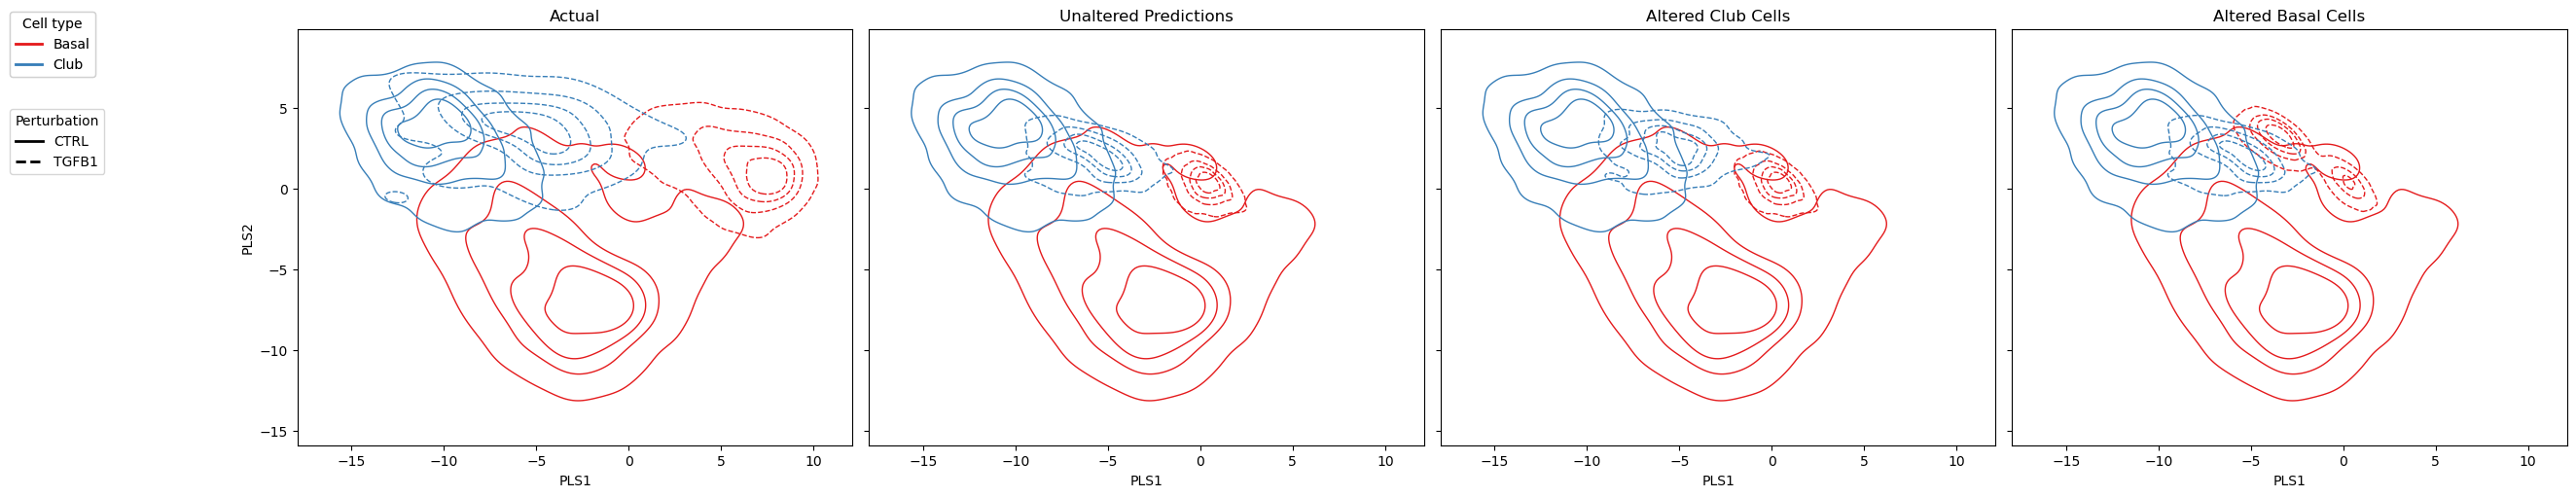

In [65]:
fig, axes = plot_pls_kde_grid(
    [X_pls_actual, X_pls_pred_unaltered_both, X_pls_pred_altered_club, X_pls_pred_altered_basal],
    ['Actual', 'Unaltered Predictions', 'Altered Club Cells', 'Altered Basal Cells'],
    cat_col, pert_col, ctrl_pert, pert,
)


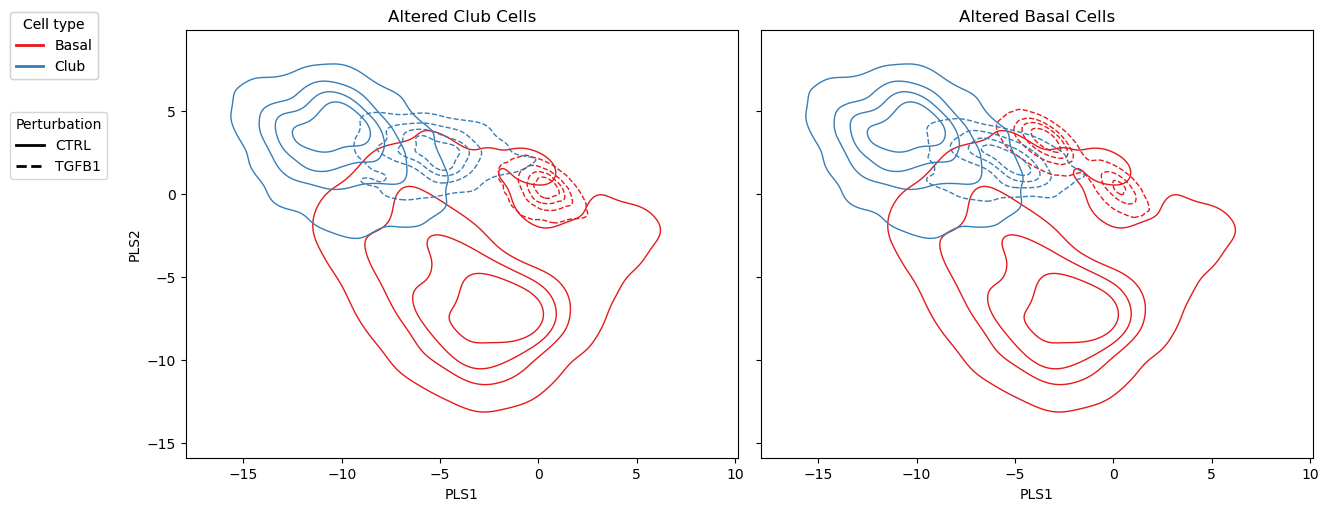

In [97]:
fig, axes = plot_pls_kde_grid(
    [X_pls_pred_altered_club, X_pls_pred_altered_basal],
    ['Altered Club Cells', 'Altered Basal Cells'],
    cat_col, pert_col, ctrl_pert, pert,
)


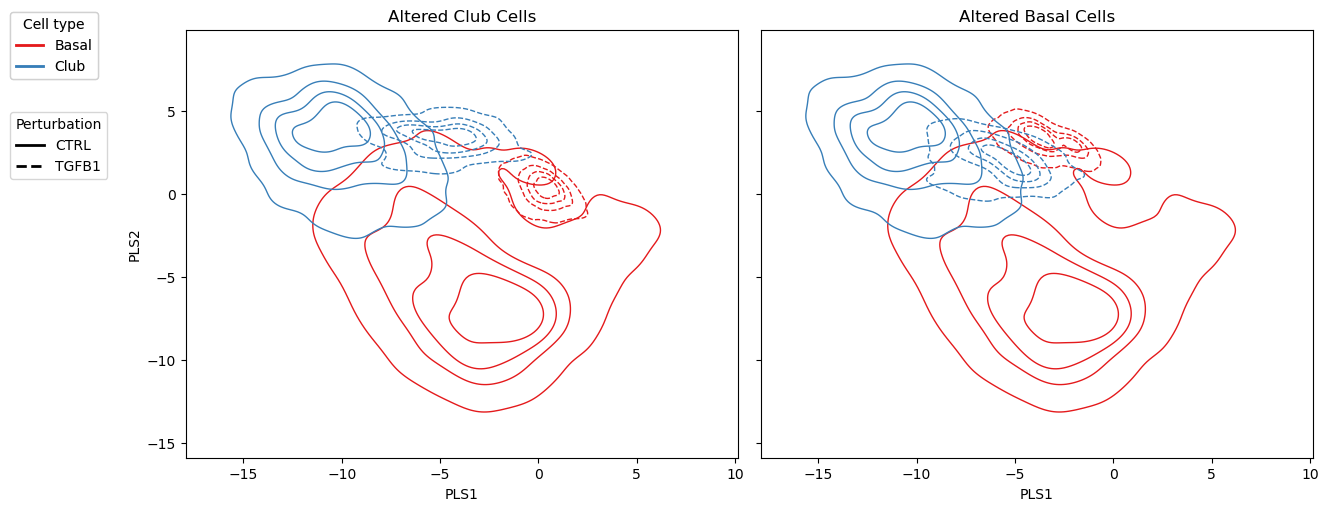

In [75]:
fig, axes = plot_pls_kde_grid(
    [X_pls_pred_altered_club, X_pls_pred_altered_basal],
    ['Altered Club Cells', 'Altered Basal Cells'],
    cat_col, pert_col, ctrl_pert, pert,
)
